In [1]:
import sys
sys.path.append('/content/yad2k')  # or the path to your yad2k folder


In [2]:
import argparse
import os
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import scipy.io
import scipy.misc
import numpy as np
import pandas as pd
import PIL
import tensorflow as tf
from keras import backend as K
from keras.layers import Input, Lambda, Conv2D
from keras.models import load_model, Model
from yolo_utils import read_class_names, read_anchors, generate_colors, preprocess_image, draw_boxes, scale_boxes
from yad2k.yad2k.models.keras_yolo import yolo_head, yolo_boxes_to_corners, preprocess_true_boxes, yolo_loss, yolo_body

%matplotlib inline


/tmp/ipython-input-1579825292.py:6: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


## 1. The Problem statement ....

We are working on a self-drinving car.As a critiacl component of this project, we'd like to build a car detection system. To collect the data, we've mounted a camera to the top of the car, which take the pictures of the road ahead every few secs as we drive.


As an eg: here's how the bounding boxes look like
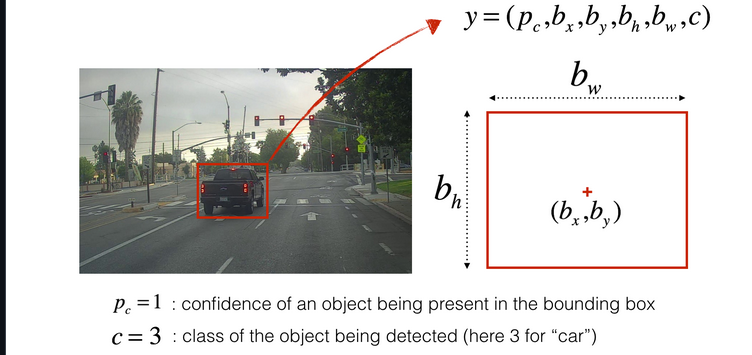

If you have 80 classes that you want YOLO to recognize, you can represent the class label c either as an integer from 1 to 80, or as an 80-dimensional vector (with 80 numbers) one component of which is 1 and the rest of which are 0. We will use both representations, depending on which is more convenient for a particular step.



## YOLO - You only look once
Is a popular algorithm because it achieves high accuracy while also being able to run in real-time. This algorithm "only look once" at the image in the sense that it requires only one forward propagation pass through the network to make predictions. After non-max suppression, it then outputs recognized objects together with the bounding boxes.


## Model Details
First things to know:

The input of each batch of images of shapes (m, 608, 608, 3)
* The output is a list of bounding boxes along with the recongnized classes. Each bounding box is represented by 6 numbers $$ (p_c. b_x, b_h, b_w, c) $$ as explaine above.
 If you expand c into an 80-dimensional vector, each bounding box is then represented by 85 numbers.

 with 5 anchor boxes, we can think of the YOLO archirecture as follows: IMAGE (m, 608, 609, 3) -> DEEP CNN -> ENCODING (m, 19, 19, 85)
 In greater details:
 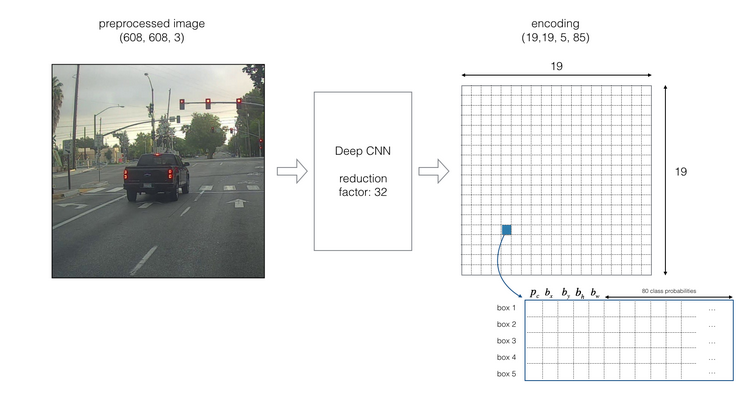


If the center/midpoint of an object falls into a grid cell, that grid cell is responsible for detecting that object.

Since we are using 5 anchor boxes, each of the 19 x19 cells thus encodes information about 5 boxes. Anchor boxes are defined only by their width and height.

For simplicity, we will flatten the last two last dimensions of the shape (19, 19, 5, 85) encoding. So the output of the Deep CNN is (19, 19, 425).

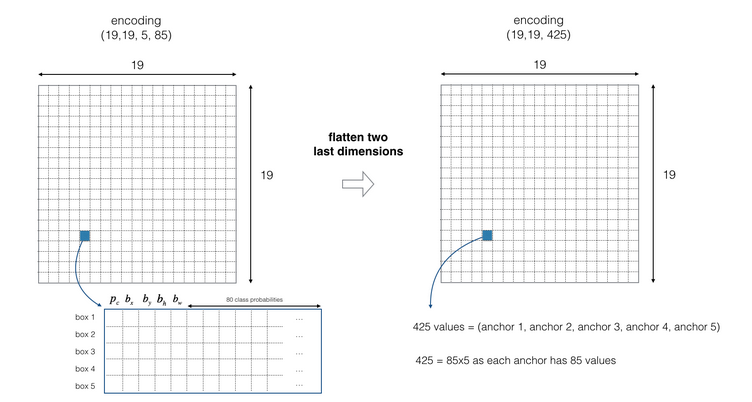

Now for each box we will compute the following elementwise product and extract a probability that the box contains a certain class.

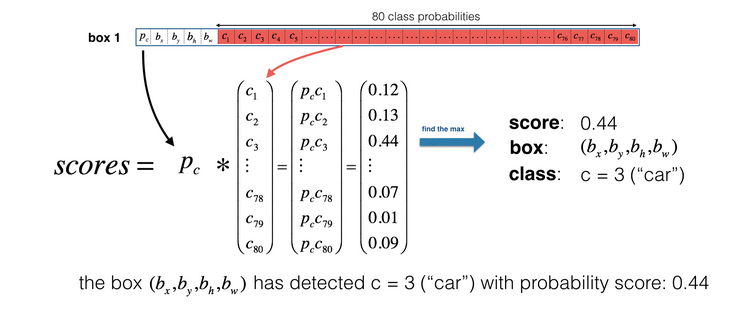

One  way to visualize what YOLO is predicting on an image:
* For each of the 19x19 grid cells, find the maximum of the probability scores (taking a max across both the 5 anchor boxes and across different classes).
* Color that grid cell according to what object that grid cell considers the most likely.

Doing this results in this picture:
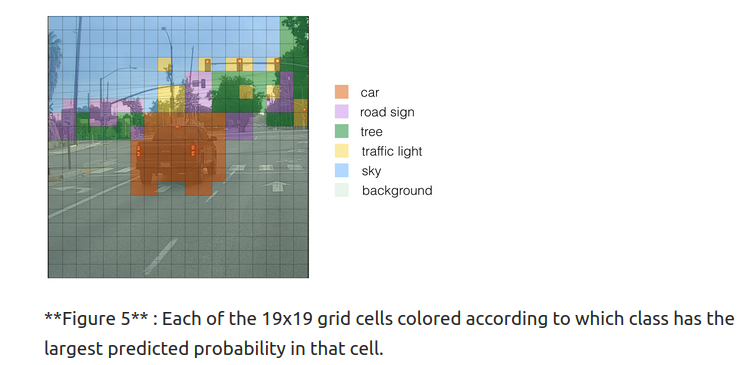

Another way to visualize YOLO's output is to plot the bounding boxes that it outputs. Doing that results in a visualization like this:



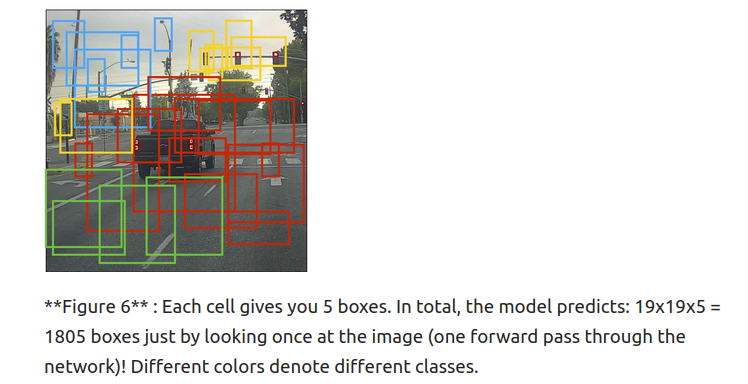

In the figure above, we plotted only boxes that the model had assigned a high probability to, but this is still too many boxes. You'd like to filter the algorithm's output down to a much smaller number of detected objects. To do so, you'll use non-max suppression. Specifically, you'll carry out these steps:

* Get rid of boxes with a low score (meaning, the box is not very confident about detecting a class)
* Select only one box when several boxes overlap with each other and detect the same object.

## Filtering with threshold on class scores
You are going to apply a first filter by thresholding. You would like to get rid of any box for which the class "score" is less than a chosen threshold.

The model gives a total of 19x19x5x85 numbers , with each box is described by 85 numbers. It'll be convenient to rearrange the (19, 19, 5, 85) or (19,19, 425) dim: tensor into as following variables:


* `box_confidence:` tensor of shape (19,19, 5, 1) containing $$p_c$$(confidence probability that there's some object) for each of the 5 boxes predicted in each of the 19x19 cells.
* boxes: tensor of shape (19 x 19, 5, 4) containing $$(b_x, b_y, b_h, b_w)for each of the 5 boxes per cell.

 * box_class_probs: tensor of shape (19x19, 5, 80) containing the detection probabilities (c1, c1, ...c80) for each of the 80 classes for each of the 5 boxes per cell.


In [3]:
import tensorflow as tf

def yolo_filter_boxes(box_confidence, boxes, box_class_probs, threshold = .6):
  """
  Filter YOLO boxes by thresholding on the object and class confidence

  Arguments:
  box_confidence -- tensor of shape (19,19, 5, 1)
  boxes -- tensor of shape (19, 19, 5, 4)
  box_class_probs -- tensor of shape (19, 19, 5, 80)
  threshold -- real value, if [ highest class probability score < threshold], then get rid of the corresponding box

  Returns :
  scores -- tensor of shape (None,), containing the class probability score for selected boxes
  boxes -- tensor of shape (None, 4), containing (b_x, b_y, b_h, b_w) coordinates of selected boxes
  classes -- tensor of shape (None,), containing the index of the class detected by the selected boxes


  Note: "None" is here because you don't know the exact number of selected boxes, as it depends on the threshold.
  For example, the actual output size of scores would be (10,) if there are 10 boxes.
  """
  box_scores = tf.multiply(box_confidence, box_class_probs)

  # Find the box_classes thank to the max_box_scores, keep track of the corresponding score
  box_classes = tf.argmax(box_scores, axis=-1)
  box_class_scores = tf.reduce_max(box_scores, axis=-1)


  # Create filtering mask based on "box_class_scores" by using "threshold". The mask should have
  # the same dimension as box_class_scores, and be True for boxes you want to keep (with probability >= threshold)
  filtering_mask = box_class_scores >= threshold

  # Apply the mask to scores, boxes and classes
  scores = tf.boolean_mask(box_class_scores, filtering_mask)
  boxes = tf.boolean_mask(boxes, filtering_mask)
  classes = tf.boolean_mask(box_classes, filtering_mask)

  return scores, boxes, classes


In [4]:
import tensorflow as tf

box_confidence = tf.random.normal([19, 19, 5, 1], mean=1.0, stddev=4.0, seed=1)
boxes = tf.random.normal([19, 19, 5, 4], mean=1.0, stddev=4.0, seed=1)
box_class_probs = tf.random.normal([19, 19, 5, 80], mean=1.0, stddev=4.0, seed=1)

scores, boxes, classes = yolo_filter_boxes(
    box_confidence,
    boxes,
    box_class_probs,
    threshold=0.5
)

print("scores[2] =", scores[2].numpy())
print("boxes[2] =", boxes[2].numpy())
print("classes[2] =", classes[2].numpy())

print("scores.shape =", scores.shape)
print("boxes.shape =", boxes.shape)
print("classes.shape =", classes.shape)


scores[2] = 16.064978
boxes[2] = [ 1.0273384 -2.1178942  4.8872733 -4.0143332]
classes[2] = 78
scores.shape = (1786,)
boxes.shape = (1786, 4)
classes.shape = (1786,)


## Non max suppression
Even after filtering by thresholding over the classes scores, we still end up a lot of overlapping boxes. A second filter for selecting the right boxes is called non-maximum suppression (NMS)
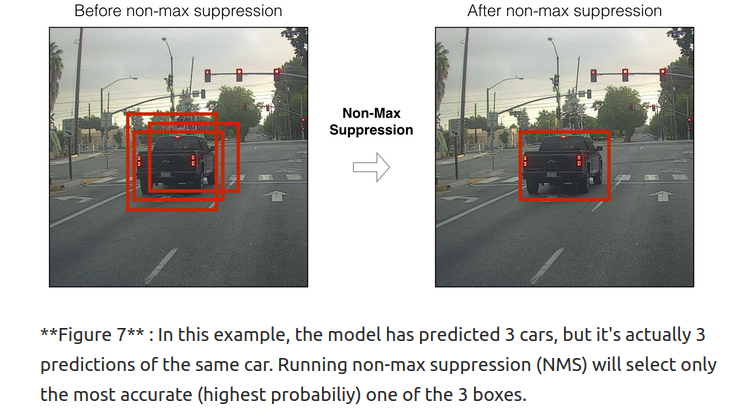


Non max suppression uses the very important function called **Intersection over Union** or **IoU**
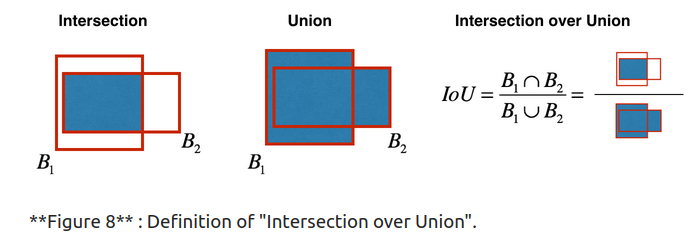



* Here we define a box using its 2 corners (upper left and lower right) (x1, y1, x2, y2) rather than the midpoint and height/width

* TO calculate the area of the rectangle you need to multiply its height (y2-y1) by its width (x2-x1)

* We'll also need to find coordinates (xi1, yi1, xi2, yi2) of the itersection of two boxes. And here
   * xi1 = max: of the x1 coord: of the 2 boxes
   * yi1 = max: of the y1 coord: of the 2 boxes
   * xi2 = min of the x2 coord: of the 2 boxes
   * yi2 = min: of the y2 coord: of the 2 boxes.
   In this code, we use the convention that (0,0) is the top-left corner of an image, (1,0) is the upper-right corner, and (1,1) the lower-right corner.
   

In this code, we use the convention that (0,0) is the top-left corner of an image, (1,0) is the upper-right corner, and (1,1) the lower-right corner.

In [5]:
def iou(box1, box2):
  """ Implements the intersection over the union (IoU) between box1 and box2

  Arguments:
       box1 -- first box , list objects with coords: (x1, y1, x2, y2)
       box2 --- second box, list objects with coords: (x1, y1, x2, y2)

  """
  xi1 = max(box1[0], box2[0])
  yi1 = max(box1[1], box2[1])
  xi2 = min(box1[2],box2[2])
  yi2 = min(box1[3], box2[3])

  inter_area = (xi2 - xi1) * (yi2 - yi1)


  box1_area = (box1[3] - box1[1]) * (box1[2] - box1[1])
  box2_area = (box2[3] - box2[1]) * (box2[2] - box2[0])

  union_area = box1_area + box2_area - inter_area

  # Compute IoU
  iou = inter_area / union_area
  return iou



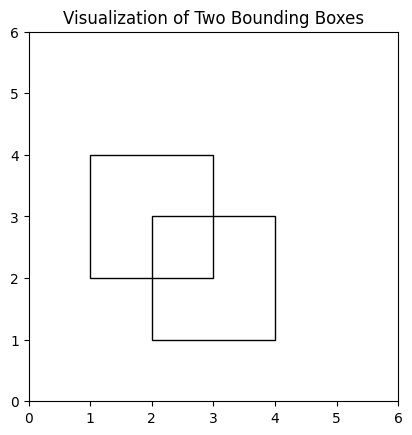

In [6]:
import matplotlib.pyplot as plt

# Define two boxes: (x1, y1, x2, y2)
box1 = (2, 1, 4, 3)
box2 = (1, 2, 3, 4)

fig, ax = plt.subplots()

# Draw box1
ax.add_patch(
    plt.Rectangle(
        (box1[0], box1[1]),
        box1[2] - box1[0],
        box1[3] - box1[1],
        fill=False
    )
)

# Draw box2
ax.add_patch(
    plt.Rectangle(
        (box2[0], box2[1]),
        box2[2] - box2[0],
        box2[3] - box2[1],
        fill=False
    )
)

ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_aspect("equal")
ax.set_title("Visualization of Two Bounding Boxes")

plt.show()


In [7]:
box1 = (2, 1, 4, 3)
box2 = (1, 2, 3, 4)
print("iou = " + str(iou(box1, box2)))

iou = 0.1111111111111111


Now we implement the non max suppression. The key steps are:
1. select the box that has the highest score.
2. Compute its overlap with all other boxes , and remove boxes that overlap it more than `iou_threshold`
3. Go back to step1 and iterate until there's no more boxes with a lower score than the current selected box.


This will remove all boxes that have a large overlap with the selected boxes. Only the "best" boxes remain.

In [8]:
import tensorflow as tf

def yolo_non_max_suppression(scores, boxes, classes, max_boxes = 10, iou_threshold= 0.5):
  """
   Applies Non-max suppression (NMS) to set of boxes

    Arguments:
    scores -- tensor of shape (None,), output of yolo_filter_boxes()
    boxes -- tensor of shape (None, 4), output of yolo_filter_boxes() that have been scaled to the image size (see later)
    classes -- tensor of shape (None,), output of yolo_filter_boxes()
    max_boxes -- integer, maximum number of predicted boxes you'd like
    iou_threshold -- real value, "intersection over union" threshold used for NMS filtering

    Returns:
    scores -- tensor of shape (, None), predicted score for each box
    boxes -- tensor of shape (4, None), predicted box coordinates
    classes -- tensor of shape (, None), predicted class for each box

    Note: The "None" dimension of the output tensors has obviously to be less than max_boxes. Note also that this
    function will transpose the shapes of scores, boxes, classes. This is made for convenience.

  """

  # Use tf.image.non_max_suppression() to get the list of indices corresponding to boxes you keep
  nms_indices = tf.image.non_max_suppression(
      boxes,
      scores,
      max_boxes,
      iou_threshold=iou_threshold
  )

  # Select only nms_indices from scores, boxes and classes
  scores = tf.gather(scores, nms_indices)
  boxes = tf.gather(boxes, nms_indices)
  classes = tf.gather(classes, nms_indices)

  return scores, boxes, classes


In [9]:
import tensorflow as tf

# Create dummy inputs
scores = tf.random.normal([54], mean=1.0, stddev=4.0, seed=1)
boxes = tf.random.normal([54, 4], mean=1.0, stddev=4.0, seed=1)
classes = tf.random.uniform([54], minval=0, maxval=80, dtype=tf.int32, seed=1)

# Apply NMS
scores, boxes, classes = yolo_non_max_suppression(scores, boxes, classes)

# Print values (TF-2 way)
print("scores[2] =", scores[2].numpy())
print("boxes[2] =", boxes[2].numpy())
print("classes[2] =", classes[2].numpy())

print("scores.shape =", scores.shape)
print("boxes.shape =", boxes.shape)
print("classes.shape =", classes.shape)


scores[2] = 6.082263
boxes[2] = [ 4.110873   2.544206   2.1469054 -1.5198021]
classes[2] = 4
scores.shape = (10,)
boxes.shape = (10, 4)
classes.shape = (10,)


## Wrapping up the filtering

It's time for implementing the fun: taking the output of the deep CNN (the 19x19x5x85 dimenisonal encoding) and filtering through all the boxes using the functions we've implemented.


`yolo_eval()` which takes the output of the YOLO encoding and filters the boxes using  score threshold and NMS.

* There're a few ways of representing boxes, such as via their corners or via their midpoint and height/width. YOLO converts between a few such formats at different times, using the following functions (which we have provided):

boxes = yolo_boxes_to_corners(box_xy, box_wh)
which converts the yolo coordinates (x, y, w, h) to box corner's coord: (x1, y1, x2, y2) to fit the input of the `yolo_filter_boxes`
boxes = scale_boxes(boxes, image_shape)


In [10]:
import tensorflow as tf

def yolo_eval(yolo_outputs, image_shape = (720., 1280.),max_boxes=10, score_threshold=.6, iou_threshold=.5):
  """
  Converts the output of YOLO encoding (a lot of boxes) to your predicted boxes along with their scores, box coordinates and classes.
  Arguments:
    yolo_outputs -- output of the encoding model (for image_shape of (608, 608, 3)), contains 4 tensors:
                    box_confidence: tensor of shape (None, 19, 19, 5, 1)
                    box_xy: tensor of shape (None, 19, 19, 5, 2)
                    box_wh: tensor of shape (None, 19, 19, 5, 2)
                    box_class_probs: tensor of shape (None, 19, 19, 5, 80)
    image_shape -- tensor of shape (2,) containing the input shape, in this notebook we use (608., 608.) (has to be float32 dtype)
    max_boxes -- integer, maximum number of predicted boxes you'd like
    score_threshold -- real value, if [ highest class probability score < threshold], then get rid of the corresponding box
    iou_threshold -- real value, "intersection over union" threshold used for NMS filtering

    Returns:
    scores : tensor of shape (None), predicted score for each box
    boxes : tensor of shape (None, 4), predicted box coordinates
    classes: tensor of shape (None, ), predicted class for each box
  """
  # Retrieve outputs of the YOLO model (~` line)
  box_confidence, box_xy, box_wh, box_class_probs = yolo_outputs

  # Convert boxes to be ready for filtering functions
  boxes = yolo_boxes_to_corners(box_xy, box_wh)

  # Filter boxes by score threshold
  scores, boxes, classes = yolo_filter_boxes(
      box_confidence,
      boxes,
      box_class_probs,
      threshold=score_threshold
  )

  # Scale boxes to image shape
  image_shape = tf.cast(image_shape, tf.float32)
  height, width = image_shape[0], image_shape[1]

  scale = tf.stack([height, width, height, width])
  boxes = boxes * scale

  # Apply Non-max suppression
  scores, boxes, classes = yolo_non_max_suppression(
      scores,
      boxes,
      classes,
      max_boxes=max_boxes,
      iou_threshold=iou_threshold
  )

  return scores, boxes, classes


In [11]:

    yolo_outputs = (tf.random.normal([19, 19, 5, 1], mean=1, stddev=4, seed = 1),
                    tf.random.normal([19, 19, 5, 2], mean=1, stddev=4, seed = 1),
                    tf.random.normal([19, 19, 5, 2], mean=1, stddev=4, seed = 1),
                    tf.random.normal([19, 19, 5, 80], mean=1, stddev=4, seed = 1))
    scores, boxes, classes = yolo_eval(yolo_outputs)
    print("scores[2] = " + str(scores[2].numpy()))
    print("boxes[2] = " + str(boxes[2].numpy()))
    print("classes[2] = " + str(classes[2].numpy()))
    print("scores.shape = " + str(scores.numpy().shape))
    print("boxes.shape = " + str(boxes.numpy().shape))
    print("classes.shape = " + str(classes.numpy().shape))




scores[2] = 155.8359
boxes[2] = [-1392.284  -5958.1924  1185.1492 -4086.6467]
classes[2] = 75
scores.shape = (10,)
boxes.shape = (10, 4)
classes.shape = (10,)



**Summary for YOLO**: - Input image (608, 608, 3) - The input image goes through a CNN, resulting in a (19,19,5,85) dimensional output. - After flattening the last two dimensions, the output is a volume of shape (19, 19, 425): - Each cell in a 19x19 grid over the input image gives 425 numbers. - 425 = 5 x 85 because each cell contains predictions for 5 boxes, corresponding to 5 anchor boxes, as seen in lecture. - 85 = 5 + 80 where 5 is because $$(p_c, _x, b_y, b_h, b_w) $$ has 5 numbers, and and 80 is the number of classes we'd like to detect - You then select only few boxes based on: - Score-thresholding: throw away boxes that have detected a class with a score less than the threshold - Non-max suppression: Compute the Intersection over Union and avoid selecting overlapping boxes - This gives you YOLO's final output.

## Test YOLO pretrained model on images

Here we use the pretrained model and test it on the car detection dataset. As usual we start by **creating a session to start the graph**


In [12]:
# sess = K.get_session   # works for older version
import tensorflow as tf

# Create a constant tensor
t = tf.constant([[1, 2], [3, 4]])
# print(t)

# Convert tensor to numpy
value = t.numpy()



In [13]:
!git clone https://github.com/qqwweee/keras-yolo3

fatal: destination path 'keras-yolo3' already exists and is not an empty directory.


In [14]:
import os

patches = {
    "from keras.layers.advanced_activations import LeakyReLU": "from keras.layers import LeakyReLU",
    "from keras.layers.normalization import BatchNormalization": "from keras.layers import BatchNormalization",
    "from keras.utils.vis_utils import plot_model": "from keras.utils import plot_model"
}

folder = "keras-yolo3"  # path to YOLO repo

for filename in os.listdir(folder):
    if filename.endswith(".py"):
        path = os.path.join(folder, filename)
        with open(path, "r") as f:
            content = f.read()
        for old, new in patches.items():
            content = content.replace(old, new)
        with open(path, "w") as f:
            f.write(content)

print("All YOLO repo imports patched for Keras 3!")


All YOLO repo imports patched for Keras 3!


In [15]:
mkdir -p keras-yolo3/model_data

In [16]:
from keras.models import load_model
from yolo_utils import read_class_names, read_anchors
import numpy as np
import os

# anchors = read_anchors("yad2k/model_data/yolo_anchors.txt")
class_names = read_class_names("yad2k/model_data/coco_classes.txt")


## Loading a pretrained model

Training a YOLO model takes a very long time and requires a fairly large dataset of labelled bounding boxes for a large range of target classes. You are going to load an existing pretrained Keras YOLO model stored in "yolo.h5". (These weights come from the official YOLO website, and were converted using a function written by Allan Zelener. References are at the end of this notebook. Technically, these are the parameters from the "YOLOv2" model, but we will more simply refer to it as "YOLO" in this notebook.) Run the cell below to load the model from this file.

In [17]:
%cd ..


/


In [18]:
!find /content -type d -name "models"


/content/yad2k/yad2k/models


In [19]:
!wget https://raw.githubusercontent.com/allanzelener/YAD2K/master/yad2k/convert.py -P /content/yad2k/yad2k/


--2026-01-10 08:37:26--  https://raw.githubusercontent.com/allanzelener/YAD2K/master/yad2k/convert.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-01-10 08:37:27 ERROR 404: Not Found.



In [32]:
!wget https://github.com/qqwweee/keras-yolo3/releases/download/v1.0/yolo.h5 \
     -O /content/keras-yolo3/model_data/yolo.h5


--2026-01-10 08:48:36--  https://github.com/qqwweee/keras-yolo3/releases/download/v1.0/yolo.h5
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-01-10 08:48:37 ERROR 404: Not Found.



In [37]:
!python3 /content/keras-yolo3/convert.py \
  /content/keras-yolo3/yolov3.cfg \
  /content/keras-yolo3/model_data/yolov3.weights \
  /content/keras-yolo3/model_data/yolo.h5


2026-01-10 08:51:34.760616: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768035094.791369   76876 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768035094.807493   76876 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768035094.847722   76876 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768035094.847788   76876 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768035094.847794   76876 computation_placer.cc:177] computation placer alr

In [35]:
ls /content/keras-yolo3


coco_annotation.py  kmeans.py    train_bottleneck.py  yolo.py
convert.py          LICENSE      train.py             yolov3.cfg
darknet53.cfg       model_data/  voc_annotation.py    yolov3-tiny.cfg
font/               README.md    yolo3/               yolo_video.py


In [ ]:
import sys
sys.path.append("/content")

import tensorflow as tf
from tensorflow.keras.models import load_model
import os

# Path to converted YOLO model
model_path = "/content/keras-yolo3/model_data/yolo.h5"

# Check
assert os.path.exists(model_path), "yolo.h5 not found!"

# Load model
yolo_model = load_model(model_path, compile=False)

print("YOLO model is ready!")


In [27]:
import os

for root, dirs, files in os.walk("/content"):
    if "yolov3.weights" in files:
        print("FOUND:", os.path.join(root, "yolov3.weights"))


FOUND: /content/keras-yolo3/model_data/yolov3.weights


In [23]:
import os

base_path = "/content/yad2k"
for root, dirs, files in os.walk(base_path):
    print("Folder:", root)
    print("Files:", files)
    print("-"*40)


Folder: /content/yad2k
Files: ['retrain_yolo.py', 'environment.yml', 'train_overfit.py', 'README.md', 'convert.py', 'test_yolo.py', 'LICENSE', '.gitignore', '__init__.py', 'yad2k.py']
----------------------------------------
Folder: /content/yad2k/etc
Files: ['yolo.png', 'dog_small.jpg']
----------------------------------------
Folder: /content/yad2k/.git
Files: ['description', 'packed-refs', 'HEAD', 'config', 'index']
----------------------------------------
Folder: /content/yad2k/.git/logs
Files: ['HEAD']
----------------------------------------
Folder: /content/yad2k/.git/logs/refs
Files: []
----------------------------------------
Folder: /content/yad2k/.git/logs/refs/remotes
Files: []
----------------------------------------
Folder: /content/yad2k/.git/logs/refs/remotes/origin
Files: ['HEAD']
----------------------------------------
Folder: /content/yad2k/.git/logs/refs/heads
Files: ['master']
----------------------------------------
Folder: /content/yad2k/.git/branches
Files: []


In [ ]:
import os

for root, dirs, files in os.walk("/content/yad2k"):
    if "convert.py" in files:
        print("Found convert.py at:", os.path.join(root, "convert.py"))


In [ ]:
yolo_model = load_model("model_data/yolo.h5")

In [ ]:
yolo_model.summary()

## Convert output of the model to usable bounding box tensors
The output of yolo_model is a (m, 19, 19, 5, 85) tensor that needs to pass through non-trivial processing and conversion. The following cell does that for you.



In [ ]:
yolo_outputs = yolo_head(yolo_model.ouput, anchors, len(class_names))

## Filtering boxes
yolo_outputs gave us all the predicted boxes of yolo_model in the correct format.We're now ready to perform filtering and select only the best boxes. Lets now call yolo_eval, which you had previously implemented, to do this.

In [ ]:
scores, boxes, classes = yolo_eval(yolo_outputs, image_shape)

## Run the graph on an image

* Let the fun begin. We have created a (sess) graph that can be summarized as follows:
 1. yolo_model.input is given to `yolo_model` . The model is used to compute the output yolo_model.output
 2. yolo_model.output is proceeded by `yolo_head`.It gives us `yolo_outputs`
 3. `yolo_outputs` goes through a filtering function, `yolo_eval`. It outputs
he predictions: scores, boxes, and classes


Here we implement predict() which runs through the graph to test YOLO on an image.



In [ ]:
def predict(sess, image_file):
  """ Runs the graph to stored in "sess" to predict boxes for "image_file"

  Arguments:
  sess -- your tensorflow/Keras session containing the YOLO graph
  image_file -- name of an image stored in the "images" folder.

  Returns:
  out_scores -- tensor of shape (None, ), scores of the predicted boxes
  out_boxes -- tensor of shape (None, 4), coordinates of the predicted boxes

  out_classes -- tensor of shape (None, ), class index of the predicted boxes
  """
  image, image_data = preprocess_image("images/" + image_file, model_image_size=(608, 608))

  # Run the session with the correct tensors and choose the correct placeholders in the feed_dict.
  out_scores, out_boxes, out_classes = sess.run([scores, boxes, classes], feed_dict={yolo_model.input: image_data, K.learning_phase(): 0})

  # Print predictions
  print("Found {} boxes for {}".format(len(out_boxes), image_file()))
  # Generate colors for drawing bouding boxes
  colors = generate_colors(class_names)
  # Draw bounding boxes on the image_file
  draw_boxes(image, out_scores, out_boxes, out_classes, class_names, colors)
  # Save the predicted bounding box on the image
  image.save(os.path.join("out", image_file), quality=90)
  # Display the results in the notebook
  output_image = scipy.misc.imread(os.path.join("out", image_file))
  imshow(output_image)

  return out_scores, out_boxes, out_classes





In [ ]:
out_scores, out_boxes, out_classes = predict(sess, "test.jpg")